### Multi-Label Classification

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
# 주피터 노트북에서 그림을 주피터 노트북 내에 표시하도록 강제하는 명령어
%matplotlib inline 

#### torchvision.datasets.MNIST

- torchvision.datasets에 다양한 datasets 이 있음
- MNIST dataset (숫자 필기체)
    - 60,000 training 이미지, 10,000 test 이미지 (28 pixels X 28 pixels)

In [9]:
train_rawdata = datasets.MNIST(root='dataset', train=True, download=True, transform=transforms.ToTensor())
test_dateset = datasets.MNIST(root='dataset', train=False, download=True, transform=transforms.ToTensor())

print('number of training data : ', len(train_rawdata))
print('number of test data : ', len(test_dateset))

number of training data :  60000
number of test data :  10000


#### Validation dataset 분리

In [10]:
train_indices, val_indices, _ , _ = train_test_split(range(len(train_rawdata)), # x index 번호
                                              train_rawdata.targets, # y
                                              stratify=train_rawdata.targets, # y를 균등 분포
                                              test_size=0.2)

### torch.utils.data.Subset 으로 Validation dataset 생성

- torch.utils.data.Subset(데이터, 인덱스번호 리스트)로 인덱스 번호 리스트로 구성된 sub dataset 생성 가능


In [11]:
train_dataset = Subset(train_rawdata, train_indices)
validation_dataset = Subset(train_rawdata, val_indices)

#### dataset size 확인

- 일반적으로는 Train 6, Validation 2, Test 2 (6:2:2)
- 단, 준비된 데이터 사이즈에 따라, 적절히 유사하게 적용

In [12]:
print(len(train_dataset), len(validation_dataset), len(test_dateset))

48000 12000 10000


#### Mini-batch 생성

- 모델 학습시, 매 epoch 마다 데이터를 랜덤으로 섞어서 미니배치(minibatch) 로 구성하여, 학습
- 이를 손쉽게 할 수 있도록, torch.utils.data.DataLoader 제공
- torch.utils.data.DataLoader 데이터셋, batchsize=미니배치사이즈, shuffle=True)
    - shuffle=True 는 랜덤으로 섞는 옵션

> 이미지 데이터만 이므로, feature 값들에 대한 StandardScaler() 를 적용할 필요는 없음

In [13]:
BATCH_SIZE = 128

train_batches = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_batches = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_batches = DataLoader(test_dateset, batch_size=BATCH_SIZE, shuffle=False) # 테스트 배치는 번호를 섞지 않는다.


In [14]:
X_train, y_train = next(iter(train_batches))
print(X_train.shape, y_train.shape)

torch.Size([128, 1, 28, 28]) torch.Size([128])


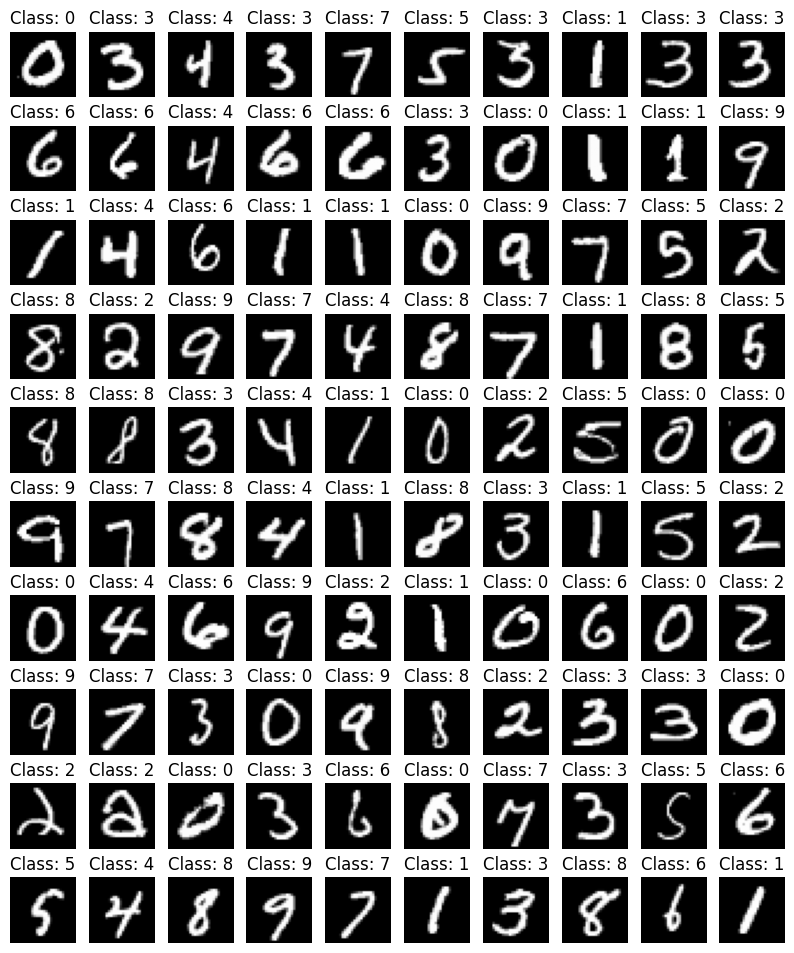

In [15]:
plt.figure(figsize=(10, 12))

X_train, y_train = next(iter(train_batches))
for index in range(100):
    plt.subplot(10, 10, index + 1)
    plt.axis('off') # x축, y축에 대한 옵션 설정
    plt.imshow(X_train[index, :, :, :].squeeze().numpy(), cmap='gray') # 가독성과 안정성 높은 방식
    # plt.imshow(X_train[index, :, :, :].numpy().reshape(28, 28), cmap='gray')
    
    plt.title('Class: ' + str(y_train[index].item()))
    

#### 모델 정의

In [16]:
X_train, y_train = next(iter(train_batches))

print(X_train.shape, y_train.shape)
print(X_train.size(0))
print(X_train.view(X_train.size(0), -1).shape) #  view() 형태를 바꾼다.

torch.Size([128, 1, 28, 28]) torch.Size([128])
128
torch.Size([128, 784])


In [22]:
class FunModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
    
        self.linear_layers = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0,1),
            nn.Linear(256, 256),
            nn.LeakyReLU(0,1),
            nn.Linear(256, 128),
            nn.LeakyReLU(0,1),
            nn.Linear(128, output_dim),
            nn.Softmax(dim=-1)
        )
        
    def forward(self, x):
        y = self.linear_layers(x)
        return y
    
minibatch_size = 128
input_dim = 28 * 28 # 784
output_dim = 10
model = FunModel(input_dim, output_dim)

loss_func = nn.CrossEntropyLoss() # log softmax는 NLLLoss() 로 진행해야 함
optimizer = torch.optim.Adam(params=model.parameters())

In [23]:
for param in model.parameters():
    print(param)

Parameter containing:
tensor([[ 1.2574e-02, -1.8143e-02,  9.7605e-03,  ...,  3.6980e-03,
         -2.7960e-02, -9.0209e-03],
        [-2.3819e-02,  1.1972e-03, -1.2058e-03,  ...,  2.0374e-02,
         -1.1884e-02,  2.4032e-03],
        [-1.1207e-02,  2.5047e-02, -1.8739e-02,  ..., -3.6645e-03,
          1.0423e-02,  1.5298e-02],
        ...,
        [-3.5479e-04,  1.4350e-02, -2.7539e-02,  ..., -2.3981e-02,
          2.2319e-03, -1.3132e-02],
        [-8.7909e-03, -2.8627e-02, -2.0556e-02,  ...,  4.1842e-05,
         -3.2119e-02,  3.2910e-02],
        [-2.3702e-02,  2.8472e-02,  3.2554e-02,  ...,  3.2076e-02,
          1.4347e-02, -3.4640e-02]], requires_grad=True)
Parameter containing:
tensor([-1.7507e-02, -1.9145e-02,  1.1349e-02, -1.4766e-02, -2.9562e-02,
        -1.6393e-02,  3.3703e-02,  2.4377e-02,  8.8241e-03,  3.1304e-02,
         2.4306e-02,  2.5941e-02,  5.1504e-03,  3.7374e-03,  2.5263e-02,
        -8.5129e-03,  9.3047e-03, -3.3710e-02,  8.2095e-03, -7.3858e-03,
         1.2

#### 베스트 모델 저장

- 모델의 학습 가능한 매개변수(예, 가중치 편향)들은 모델의 매개변수에 포함되어 있습니다.
    - model.parameters() 로 확인 가능
    - model.stat_dict() 로 각 계층의 모든 매개변수를 사전 객체로 추출 가능 (베스트 모델을 추출하기 위해 활용)
    - model.load_state_dict(x) 로 model.stat_dict() 을 통해 저장된 매개변수(x)를 가져올 수 있음

In [24]:
from copy import deepcopy # 깊은 복사 가능

#### Training Code 템플릿

- model : DNN 모델
- early_stop : Early Stopping  을 위해, 얼마의 epoch 까지 validation set에 대한 loss 가 낮아지지 않을 경우, Early Stopping 을 할지의 하이퍼 파라미터 값
- nb_epochs : 최대 epoch
- progress_interval : 진행상황을 얼마의 epoch 마다 출력할지의 epoch 값

#### model.train()과 model.eval() 기반 Validation Set 테스트

- training set 으로 학습시킬 때는 model.train() 을 호출하고,
- validation set 으로 테스트할 때는 model.eval()과 torch.no_grad() 를 호출함
     - 가중치 업데이트등의 학습을 적용하지 않고, 테스트만 진행함

> test set으로 테스트할 때에도 model.eval()과 torch.no_grad() 호출 필요

#### 이미지 각 픽셀을 feature 로 적용 (1차원으로 변형)

- x_minibatch.size(0) : 128
- x_minibatch.shape : [128, 1, 28, 28]
- x_minibatch.view(x_minibatch.size(0), -1).shape : [128, 784]

In [28]:
def train_model(model, early_stop, n_epochs, process_interval):
    
    train_losses, valid_losses, lowest_loss = list(), list(), np.inf
    
    for epoch in range(n_epochs):
        
        train_loss, valid_loss = 0, 0 # 각각의 학습 데이터, 검증 데이터의 loss를 구하기 위해 0으로 초기화 해줍니다.
        
        # --- Train ---
        model.train() # 모델 학습
        for x_minibatch, y_minibatch in train_batches:      
            y_minibatch_pred = model(x_minibatch.view(x_minibatch.size(0), -1))
            loss = loss_func(y_minibatch_pred, y_minibatch)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
    
        train_loss = train_loss / len(train_batches) # 해당 epoch의 평균 loss 값
        train_losses.append(train_loss)
    
        # validate the model
        model.eval()
        with torch.no_grad(): # 검증 데이터 셋에는 오차 역전파를 하지 않는다.
            for x_minibatch, y_minibatch in val_batches:
                y_minibatch_pred = model(x_minibatch.view(x_minibatch.size(0), -1))
                loss = loss_func(y_minibatch_pred, y_minibatch)
                valid_loss += loss.item()
                
        valid_loss = valid_loss / len(val_batches)
        valid_losses.append(valid_loss)
                        
        if valid_losses[-1] < lowest_loss:
            lowest_loss = valid_losses[-1]
            lowest_epoch = epoch
            best_model = deepcopy(model.state_dict())
        else:
            if (early_stop > 0) and lowest_epoch + early_stop < epoch:
                print('Early Stopped',epoch,"epochs")
                break   
            
        if(epoch % process_interval) == 0:
            print(train_losses[-1], valid_losses[-1], lowest_loss, lowest_epoch, epoch)

    model.load_state_dict(best_model)
    return model, lowest_loss, train_losses, valid_losses
            

In [29]:
nb_epochs = 10
progress_interval = 3
early_stop = 10

model, lowest_loss, train_losses, valid_losses = train_model(model, early_stop, nb_epochs, progress_interval)

1.4837423575719197 1.4943418528171295 1.4943418528171295 0 0
1.4812411387761435 1.4930611075238978 1.4895354940536174 1 3
1.4785557877222697 1.4898812631343274 1.4870764765333622 5 6
1.4773814261754354 1.4937775705723053 1.4870764765333622 5 9


In [30]:
valid_losses

[1.4943418528171295,
 1.4895354940536174,
 1.4906532219115725,
 1.4930611075238978,
 1.5041438404549943,
 1.4870764765333622,
 1.4898812631343274,
 1.4950078472178032,
 1.4899474521900744,
 1.4937775705723053]